# Bayesian inversion of Young's modulus in linear elasticity model

Run in **`neuralopv2`**. Requires `Results/ground_truth/data.npz` from `Generate_GroundTruth.ipynb`.

**Article parameters:** mesh 50×50 P1; prior `ac=0.005`, `cc=0.2`; log-normal `α_m=100`, `β_m=1000`; obs grid 16×16; mixed vector layout for `u`; `σ = 0.01 × mean(u_obs)`; MCMC 10000 / 500; `pcn_beta=0.15`.

**Publication flags:** `run_small_test=False` (set `True` for smoke test). See `survey_work/ArticleResultsReproduction.md`.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
ELASTICITY_DIR = os.path.join(ROOT, "survey_work/problems/hyperelasticity")

sys.path.insert(0, os.path.join(ROOT, "src/plotting"))
sys.path.insert(0, os.path.join(ROOT, "src/data"))
sys.path.insert(0, os.path.join(ROOT, "src/prior"))
sys.path.insert(0, os.path.join(ROOT, "src/mcmc"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/deeponet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/pcanet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/fno"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/mlp"))
sys.path.insert(0, ELASTICITY_DIR)

from compute_sample_errors import compute_sample_errors
from hyperelasticityModel import HyperelasticityModel
from load_data_and_deeponet import load_data_and_deeponet
from load_data_and_fno import load_data_and_fno
from load_data_and_pcanet import load_data_and_pcanet
from mcmc import MCMC
from mcmc_plot_fields import mcmc_plot_fields, mcmc_plot_fields_base
from plot_curve import plot_curve
from plot_mix_collection import get_default_plot_mix_collection_data, plot_mix_collection
from priorSampler import PriorSampler
from surrogateModel import SurrogateModel, SurrogateModelFNO

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)
torch.manual_seed(seed);

In [2]:
model_path = ELASTICITY_DIR
results_dir = os.path.join(NOTEBOOK_DIR, "Results")
os.makedirs(results_dir, exist_ok=True)

In [3]:
run_small_test = False  # True: 100 MCMC samples, test_mcmc_ prefix (smoke test only)

# Create LinearElasticityModel

In [4]:
prior_ac = 0.005
prior_cc = 0.2
prior_logn_scale = 100.0
prior_logn_translate = 1000.0
nx, ny = 50, 50
fe_order = 1

domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu = functionspace(domain, ("Lagrange", fe_order, (2,)))

prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)
model = HyperelasticityModel(Vm, Vu, prior_sampler, prior_logn_scale, prior_logn_translate, seed)
nodes = model.m_nodes


# Load surrogate models

In [5]:
surrogate_models = None
load_surrogate = True

if run_small_test:
    load_surrogate = True

In [6]:
if load_surrogate:
    def load_deeponet():
        data_path = os.path.join(model_path, "data/Hyperelasticity_samples.npz")
        nn_path = os.path.join(model_path, "DeepONet/Results/model.pkl")
        data, nn = load_data_and_deeponet(data_path, nn_path)
        print('nn_data: ', data)
        print('nn_model: ', nn)
        return SurrogateModel(model, nn, data)

    deeponet = load_deeponet()


nn_data:  <dataMethods.DataProcessor object at 0x344b99f10>
nn_model:  DeepONet(
  (branch_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2601, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=200, bias=True)
    )
  )
  (trunk_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=100, bias=True)
    )
  )
)


In [9]:
if load_surrogate and not run_small_test:
    def load_pcanet():
        data_path = os.path.join(model_path, "data/Hyperelasticity_samples.npz")
        nn_path = os.path.join(model_path, "PCANet/Results/model.pkl")
        data, nn = load_data_and_pcanet(data_path, nn_path)
        print('nn_data: ', data)
        print('nn_model: ', nn)
        return SurrogateModel(model, nn, data)

    pcanet = load_pcanet()


In [10]:
if load_surrogate and not run_small_test:
    def load_fno():
        data_path = os.path.join(model_path, "data/Hyperelasticity_FNO_samples.npz")
        nn_path = os.path.join(model_path, "FNO/Results/model.pkl")
        data, nn = load_data_and_fno(data_path, nn_path)
        # get some additional data for FNO
        trunk_nodes = deeponet.data.X_trunk
        grid_x = data.grid_x_test[0, :, :, 0]
        grid_y = data.grid_y_test[0, :, :, 0]
        nn_surrogate = SurrogateModelFNO(model, nn, data, trunk_nodes, grid_x, grid_y, u_comps = 2)
        print('nn_data: ', data)
        print('nn_model: ', nn)

    fno = load_fno()


In [7]:
if load_surrogate and not run_small_test:
    surrogate_models = {'DeepONet': deeponet} #, 'PCANet': pcanet} #, 'FNO': fno}
else:
    surrogate_models = {'DeepONet': deeponet}


In [8]:
if load_surrogate:
    t1 = time.time()
    w1 = model.samplePrior(transform_m = False)
    w2 = w1.copy()
    t2 = time.time()
    print('Time to sample m: {:.3f}'.format(t2 - t1))

    # model solver
    t1 = time.time()
    m = model.transform_gaussian_pointwise(w1)
    u_model = model.solveFwd(u = None, m = m, transform_m = False)
    t2 = time.time()
    print('Time to solve Hyperelasticity model forward: {:.3f}'.format(t2 - t1))

    # neural operators
    sm_use = surrogate_models.keys()
    for sm in sm_use:
        t1 = time.time()
        u_sm = surrogate_models[sm].solveFwd(w2)
        t2 = time.time()
        u_err = np.linalg.norm(u_model - u_sm) / np.linalg.norm(u_model)
        print('Time to solve {} forward: {:.3f}, err: {:.3e}'.format(surrogate_models[sm].model_type, t2 - t1, u_err))

Time to sample m: 0.001
Time to solve Hyperelasticity model forward: 0.713
Time to solve DeepONet forward: 0.002, err: 8.195e-01


# Load ground truth

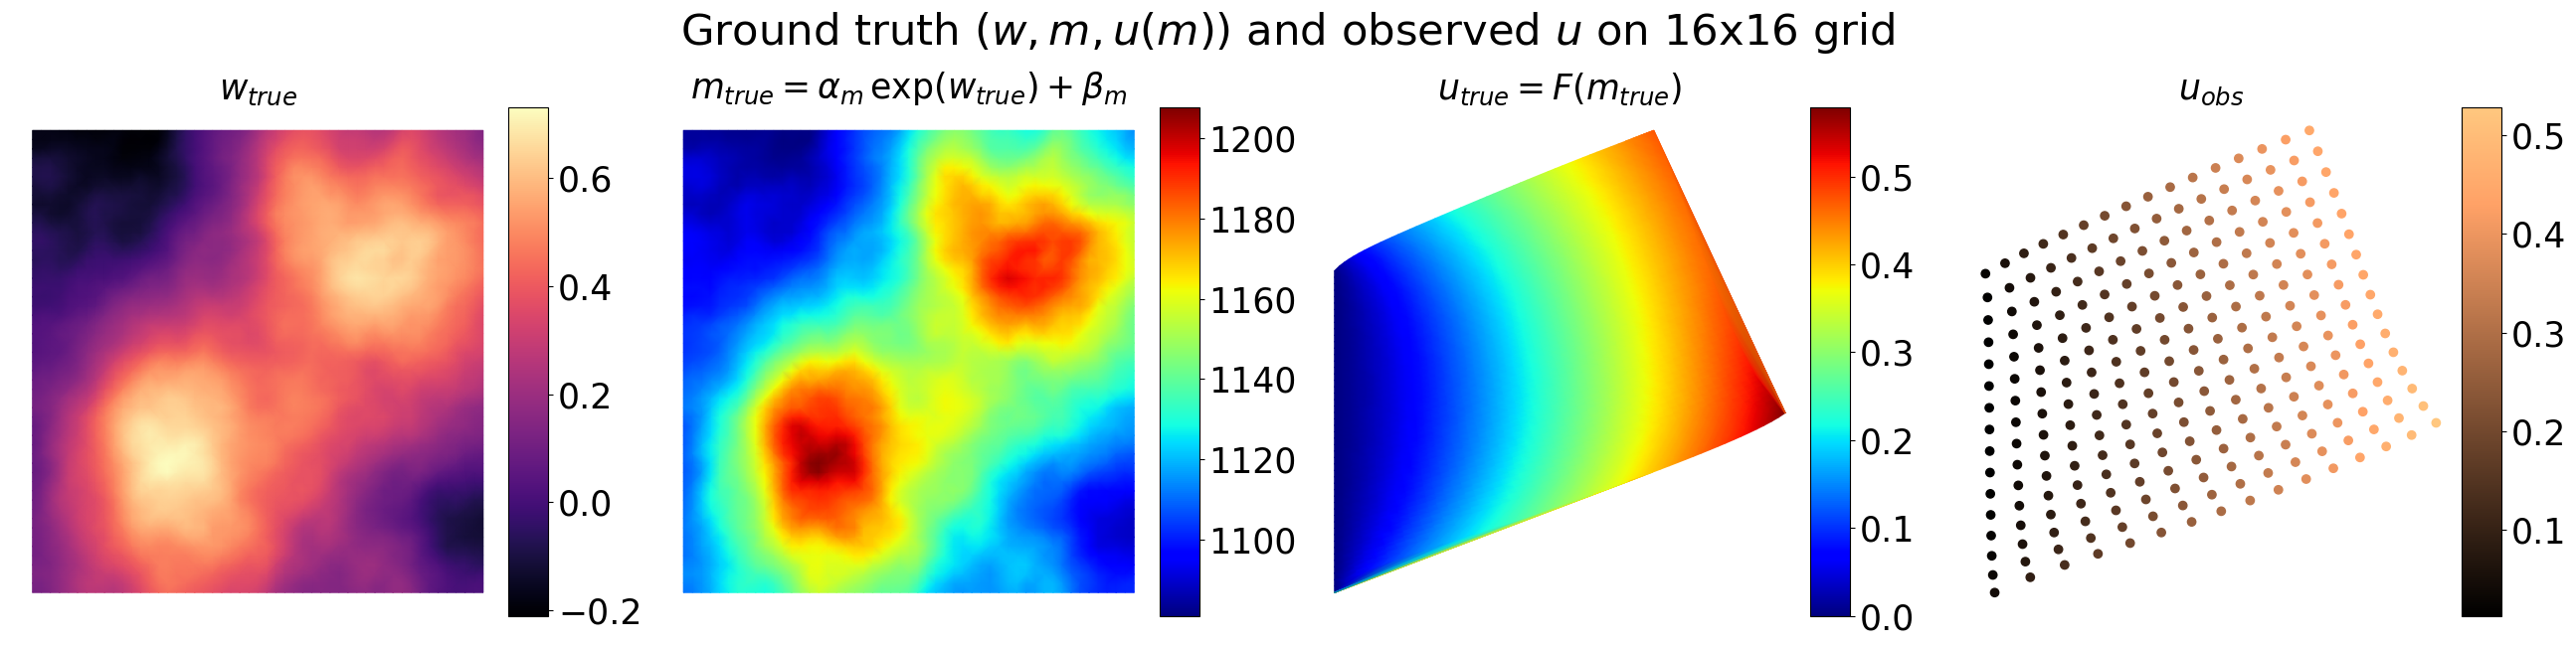

In [9]:
ground_truth_data = np.load(os.path.join(results_dir, "ground_truth/data.npz"))
num_grid_x, num_grid_y = ground_truth_data["num_grid_x"], ground_truth_data["num_grid_y"]
w_true = ground_truth_data["w_true"]
m_true = ground_truth_data["m_true"]
u_true = ground_truth_data["u_true"]
x_obs = ground_truth_data["x_obs"]
u_obs = ground_truth_data["u_obs"]

plot_data = get_default_plot_mix_collection_data(
    rows=1,
    cols=4,
    nodes=nodes,
    nodes_point_plot=x_obs,
    figsize=(26, 6),
    fs=25,
    sup_title=r"Ground truth $(w, m, u(m))$ and observed $u$ on {}x{} grid".format(num_grid_x, num_grid_y),
    y_sup_title=1.075,
    savefilename=None,
    u=[[w_true, m_true, u_true, u_obs]],
    cmap=[["magma", "jet", "jet", "copper"]],
    title=[[
        r"$w_{true}$",
        r"$m_{true} = \alpha_m\, \exp(w_{true}) + \beta_m$",
        r"$u_{true} = F(m_{true})$",
        r"$u_{obs}$",
    ]],
    is_vec=[[False, False, True, True]],
    add_disp=[[False, False, True, True]],
    plot_type=[["field", "field", "field", "point"]],
)
plot_mix_collection(plot_data)


## Compute noise

In [10]:
u_obs_mean, u_obs_std = np.mean(u_obs), np.std(u_obs)
sigma_noise = 0.01 * u_obs_mean
print(f"u_obs_mean={u_obs_mean:.3e}, u_obs_std={u_obs_std:.3e}, sigma_noise={sigma_noise:.3e}")


u_obs_mean=1.145e-01, u_obs_std=1.586e-01, sigma_noise=1.145e-03


# MCMC setup

In [11]:
pcn_beta = 0.15
surrogate_to_use = None

mcmc = MCMC(
    model,
    prior_sampler,
    ground_truth_data,
    sigma_noise=sigma_noise,
    pcn_beta=pcn_beta,
    surrogate_to_use=surrogate_to_use,
    surrogate_models=surrogate_models,
    seed=seed
)

mcmc.pp_params = {
    "curve_plot": {"fs": 12, "lw": 3, "figsize": (4, 3)},
    "field_plot": {
        "fs": 10,
        "y_sup_title": 1.025,
        "figsize": (8, 6),
        "ttl_pad": 5,
        "title_x": [0.6, 0.65, 0.65, 0.6],
        "u_vec_plot": True,
    },
}


In [12]:
n_samples = 10000
n_burnin = 500
print_every = 500
display_plot_every = 5 * print_every

if run_small_test:
    n_samples = 100
    n_burnin = 20
    print_every = 5
    display_plot_every = 2 * print_every

mcmc.surrogate_to_use = None

savepath_prefix = "mcmc_" if not run_small_test else "test_mcmc_"
savepath_base = os.path.join(
    results_dir,
    f"{savepath_prefix}n_samples_{n_samples:d}_n_burnin_{n_burnin:d}_pcn_beta_{pcn_beta:.3f}_sigma_{sigma_noise:.3e}",
)

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, "true_model")

os.makedirs(savepath, exist_ok=True)
savefilename = "tracer"


# MCMC with true model

--------------------------------------------------
MCMC started with 10000 samples and 500 burnin
PCN beta: 1.500e-01, sigma_noise: 1.145e-03
Model used for solving the forward problem: True Model
Tracer save path: true_model
Tracer save filename: tracer
--------------------------------------------------
initializing the current state. Initial cost: 8.476e+03
--------------------------------------------------
Burnin:    0, Cost: 8.476e+03
--------------------------------------------------
--------------------------------------------------
Sample:  500, Accepted samples:    0, Acceptance Rate: 0.000e+00, Cost mean: 0.000e+00. 
Tracing 500 samples took 6.404e+02s
Error (%) in w: ||w - w_mean|| = 1.000e+02, ||w - w_sample|| = 1.000e+02
Error (%) in m: ||m - m_mean|| = 4.258e+00, ||m - m_sample|| = 4.258e+00
Error (%) in u: ||u - u_mean|| = 3.030e+00, ||u - u_sample|| = 3.030e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 3.030e+00, ||u_obs - u_obs_sample|| = 3.030e+00
------------------

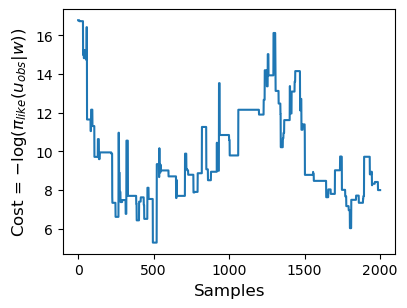

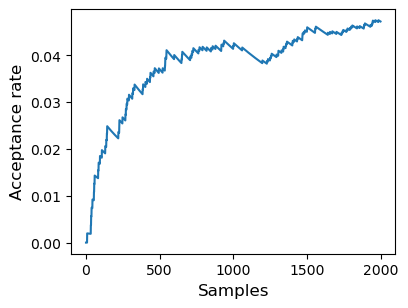

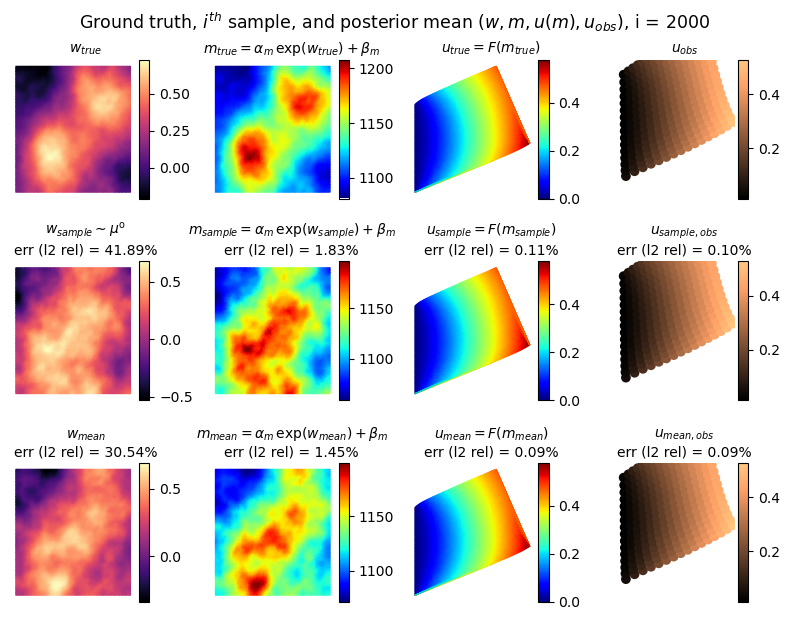

--------------------------------------------------
Sample: 3000, Accepted samples:  151, Acceptance Rate: 5.033e-02, Cost mean: 9.509e+00. 
Tracing 500 samples took 6.248e+02s
Error (%) in w: ||w - w_mean|| = 2.982e+01, ||w - w_sample|| = 3.440e+01
Error (%) in m: ||m - m_mean|| = 1.414e+00, ||m - m_sample|| = 1.511e+00
Error (%) in u: ||u - u_mean|| = 8.956e-02, ||u - u_sample|| = 9.395e-02
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 8.687e-02, ||u_obs - u_obs_sample|| = 9.068e-02
--------------------------------------------------
--------------------------------------------------
Sample: 3500, Accepted samples:  172, Acceptance Rate: 4.914e-02, Cost mean: 9.061e+00. 
Tracing 500 samples took 6.109e+02s
Error (%) in w: ||w - w_mean|| = 2.907e+01, ||w - w_sample|| = 3.746e+01
Error (%) in m: ||m - m_mean|| = 1.372e+00, ||m - m_sample|| = 1.613e+00
Error (%) in u: ||u - u_mean|| = 8.649e-02, ||u - u_sample|| = 1.009e-01
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 8.394e-02, ||u_obs - 

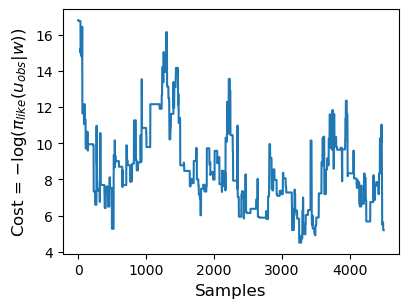

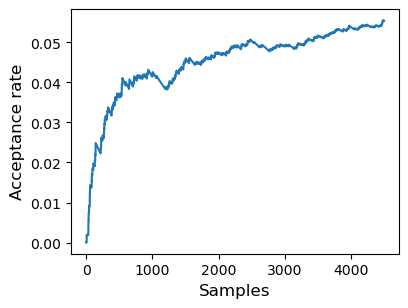

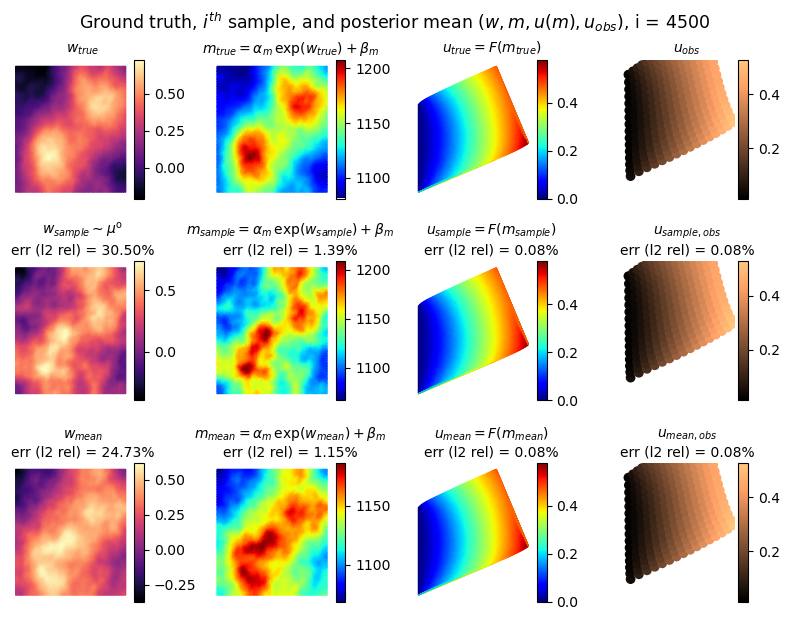

--------------------------------------------------
Sample: 5500, Accepted samples:  300, Acceptance Rate: 5.455e-02, Cost mean: 8.359e+00. 
Tracing 500 samples took 5.927e+02s
Error (%) in w: ||w - w_mean|| = 2.406e+01, ||w - w_sample|| = 3.456e+01
Error (%) in m: ||m - m_mean|| = 1.122e+00, ||m - m_sample|| = 1.528e+00
Error (%) in u: ||u - u_mean|| = 7.713e-02, ||u - u_sample|| = 1.304e-01
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 7.653e-02, ||u_obs - u_obs_sample|| = 1.305e-01
--------------------------------------------------
--------------------------------------------------
Sample: 6000, Accepted samples:  332, Acceptance Rate: 5.533e-02, Cost mean: 8.351e+00. 
Tracing 500 samples took 6.717e+02s
Error (%) in w: ||w - w_mean|| = 2.418e+01, ||w - w_sample|| = 3.561e+01
Error (%) in m: ||m - m_mean|| = 1.127e+00, ||m - m_sample|| = 1.603e+00
Error (%) in u: ||u - u_mean|| = 7.709e-02, ||u - u_sample|| = 8.828e-02
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 7.635e-02, ||u_obs - 

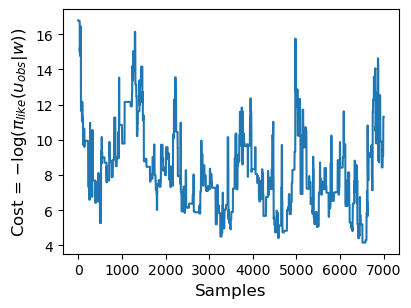

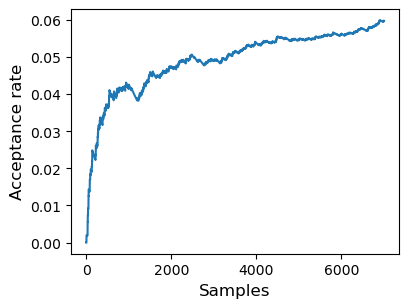

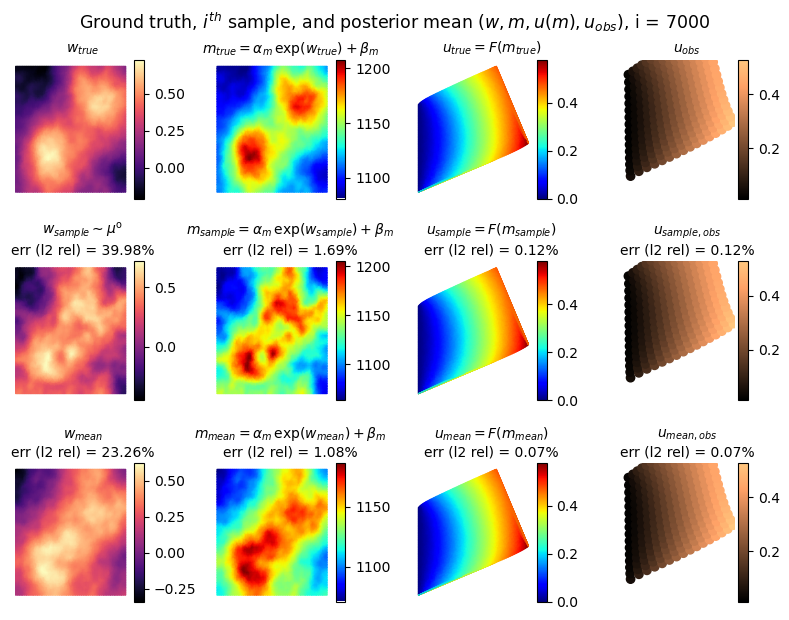

--------------------------------------------------
Sample: 8000, Accepted samples:  480, Acceptance Rate: 6.000e-02, Cost mean: 8.135e+00. 
Tracing 500 samples took 6.870e+02s
Error (%) in w: ||w - w_mean|| = 2.278e+01, ||w - w_sample|| = 2.712e+01
Error (%) in m: ||m - m_mean|| = 1.056e+00, ||m - m_sample|| = 1.227e+00
Error (%) in u: ||u - u_mean|| = 7.322e-02, ||u - u_sample|| = 8.260e-02
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 7.286e-02, ||u_obs - u_obs_sample|| = 8.231e-02
--------------------------------------------------
--------------------------------------------------
Sample: 8500, Accepted samples:  508, Acceptance Rate: 5.976e-02, Cost mean: 7.947e+00. 
Tracing 500 samples took 6.810e+02s
Error (%) in w: ||w - w_mean|| = 2.210e+01, ||w - w_sample|| = 3.676e+01
Error (%) in m: ||m - m_mean|| = 1.026e+00, ||m - m_sample|| = 1.608e+00
Error (%) in u: ||u - u_mean|| = 7.207e-02, ||u - u_sample|| = 8.278e-02
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 7.183e-02, ||u_obs - 

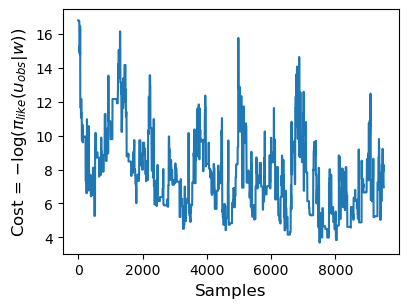

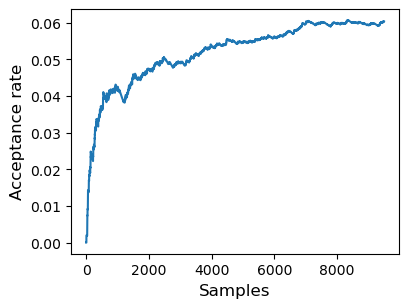

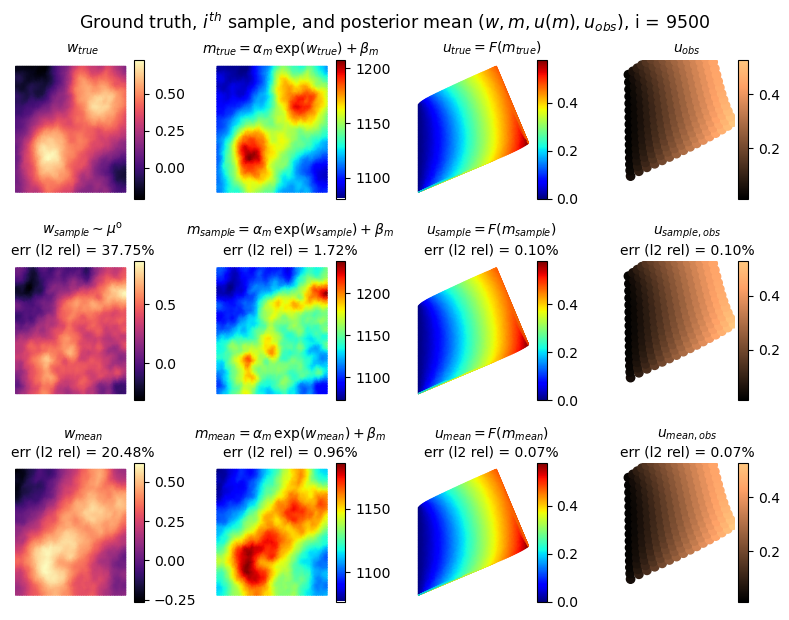

--------------------------------------------------
MCMC finished in 1.334e+04s. 
Total samples: 10500, Accepted samples:  645, Acceptance Rate: 6.143e-02, Cost mean: 7.856e+00
--------------------------------------------------


In [13]:
run_mcmc = True  

if run_mcmc or run_small_test:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        init_tracer=True,
        savepath=savepath + os.sep,
    )


## Load tracer and plot

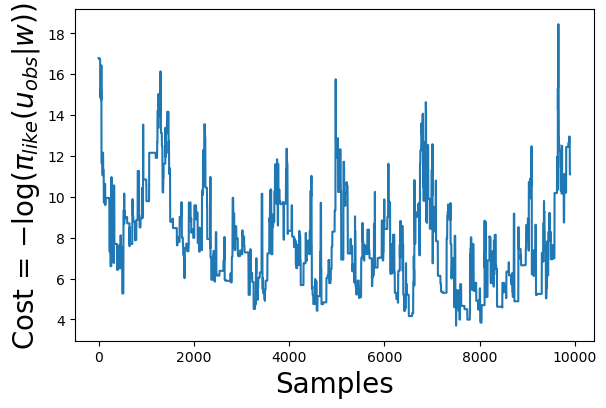

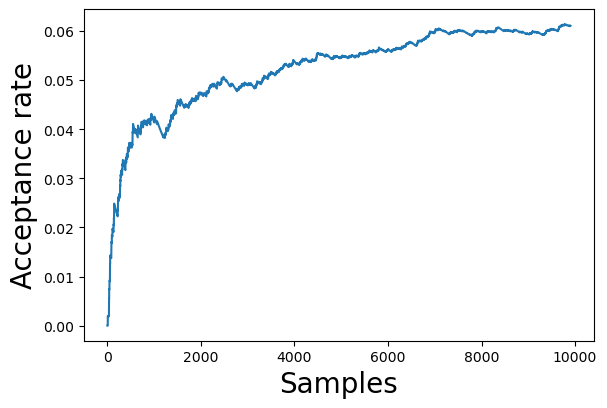

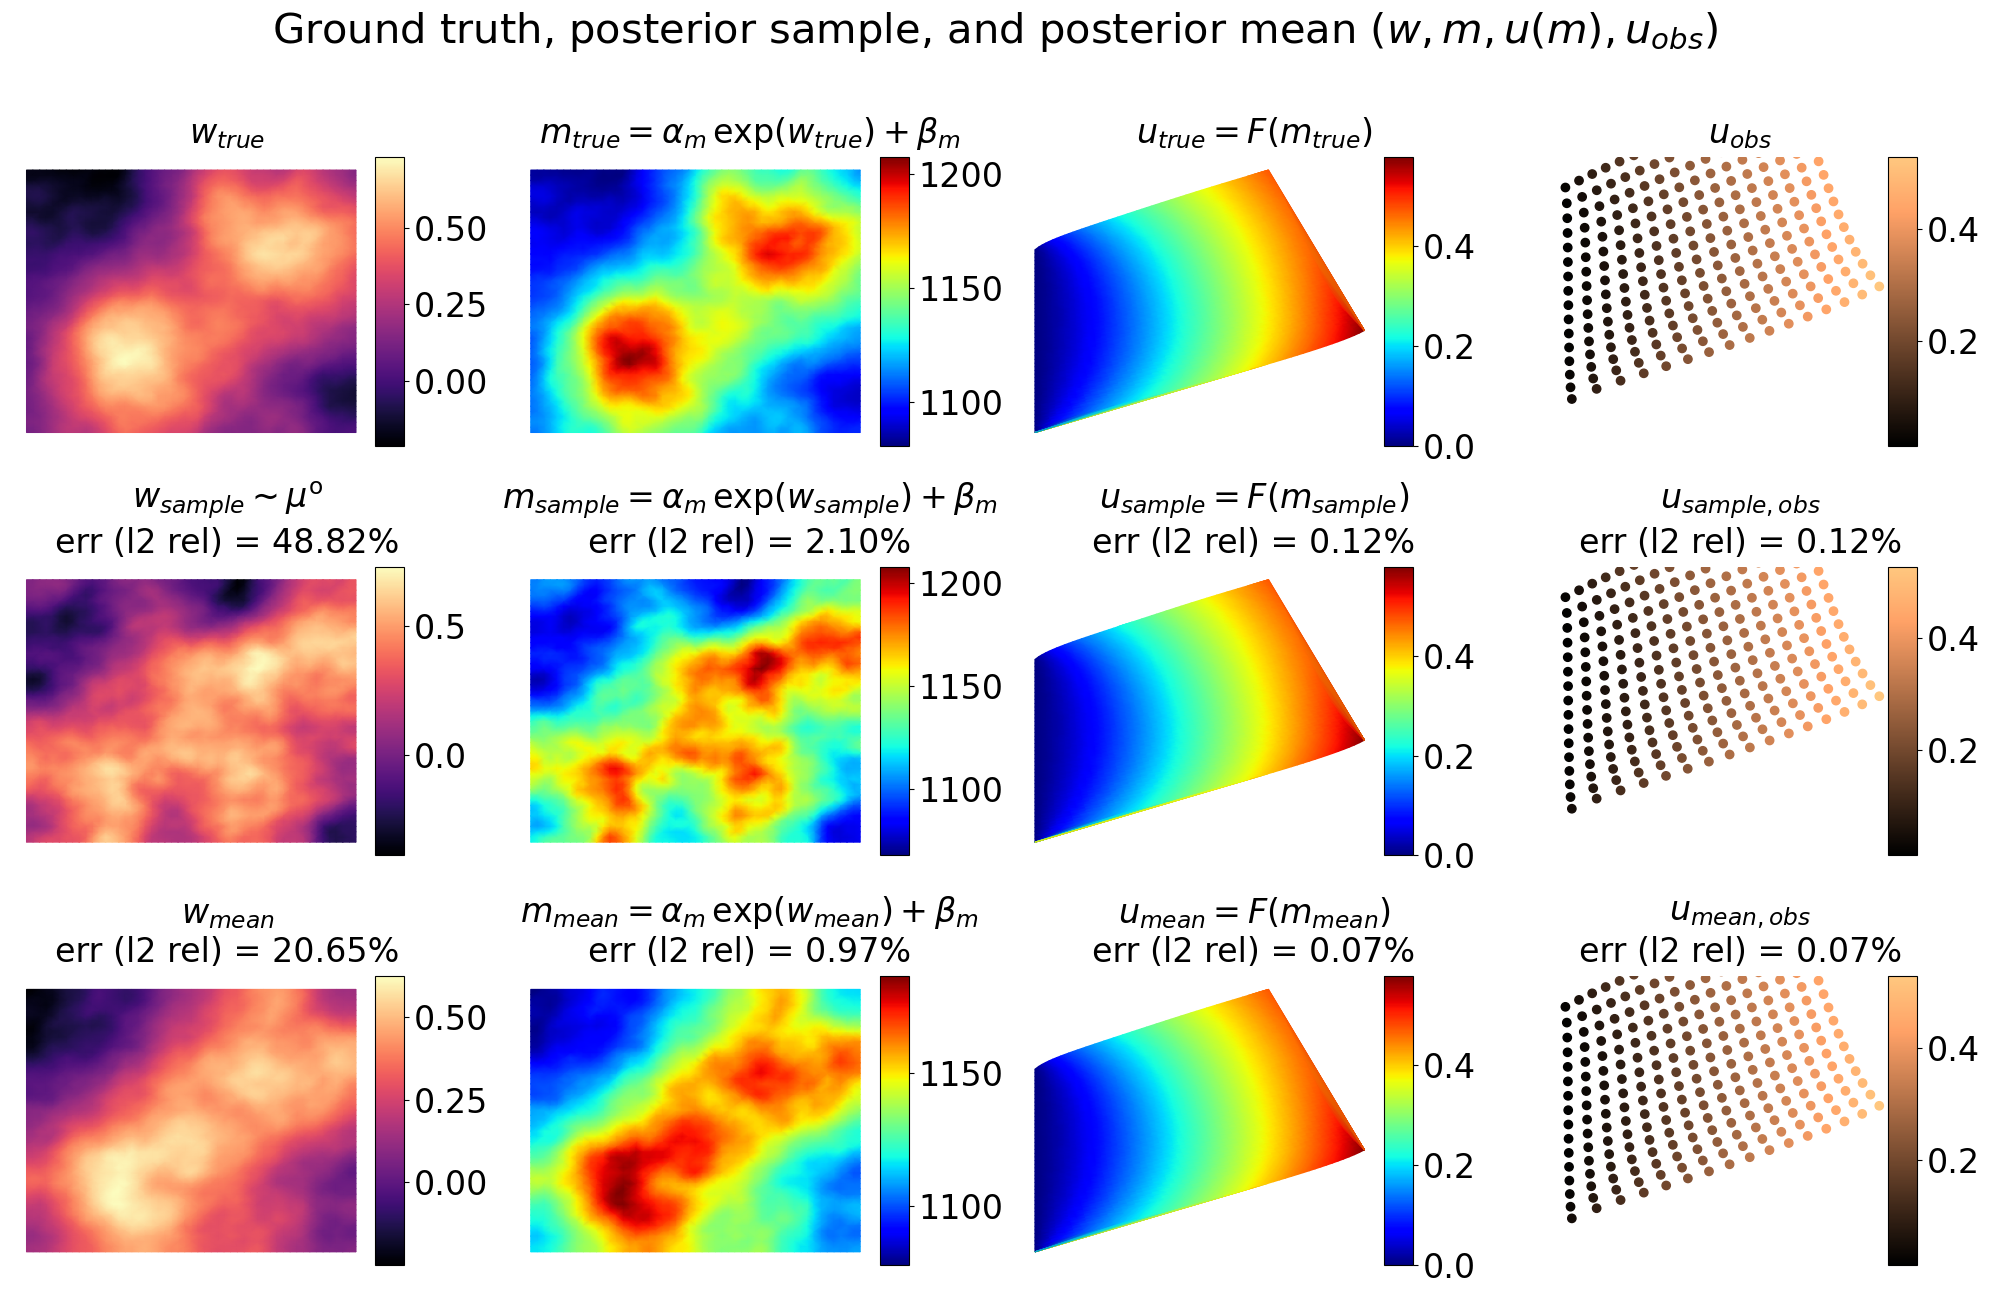

In [14]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.150_sigma_2.591e-04"
saved_results = savepath

if run_small_test:
        saved_results = savepath
        
load_tracer = pickle.load(open(os.path.join(saved_results, savefilename + ".pkl"), "rb"))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "u_vec_plot": True,
    },
}

pp_params = mcmc_pp_params["curve_plot"]
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)

w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)


# MCMC with surrogate: DeepONet

--------------------------------------------------
MCMC started with 10000 samples and 500 burnin
PCN beta: 1.500e-01, sigma_noise: 1.145e-03
Model used for solving the forward problem: DeepONet
Tracer save path: surrogate_DeepONet
Tracer save filename: tracer
--------------------------------------------------
initializing the current state. Initial cost: 5.053e+06
--------------------------------------------------
Burnin:    0, Cost: 5.053e+06
--------------------------------------------------
--------------------------------------------------
Sample:  500, Accepted samples:    0, Acceptance Rate: 0.000e+00, Cost mean: 0.000e+00. 
Tracing 500 samples took 2.029e+02s
Error (%) in w: ||w - w_mean|| = 1.000e+02, ||w - w_sample|| = 1.000e+02
Error (%) in m: ||m - m_mean|| = 4.258e+00, ||m - m_sample|| = 4.258e+00
Error (%) in u: ||u - u_mean|| = 3.030e+00, ||u - u_sample|| = 3.030e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 3.030e+00, ||u_obs - u_obs_sample|| = 3.030e+00
------------

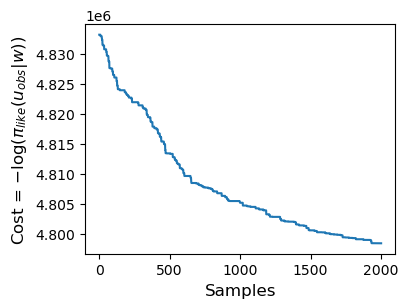

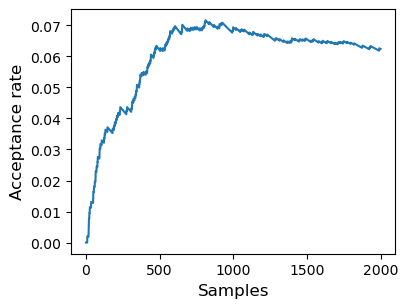

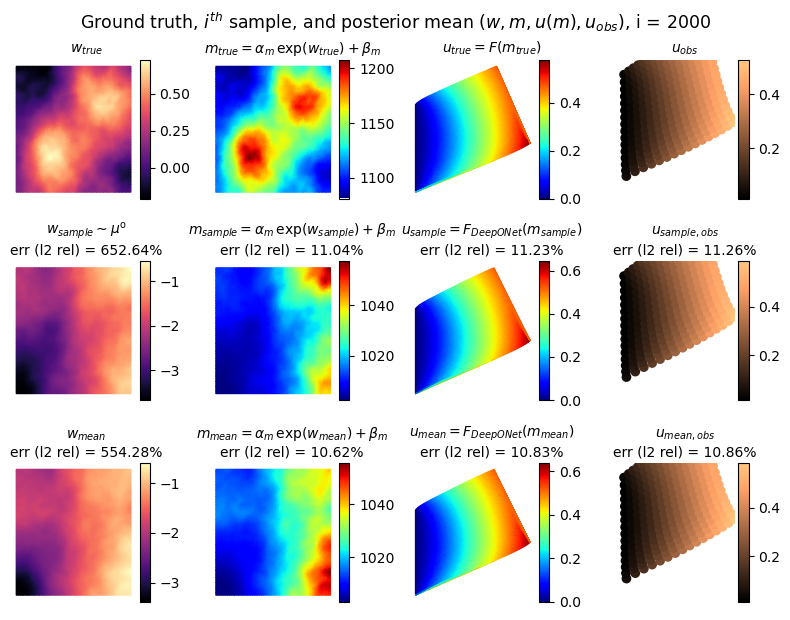

--------------------------------------------------
Sample: 3000, Accepted samples:  172, Acceptance Rate: 5.733e-02, Cost mean: 4.806e+06. 
Tracing 500 samples took 6.900e+02s
Error (%) in w: ||w - w_mean|| = 5.763e+02, ||w - w_sample|| = 6.865e+02
Error (%) in m: ||m - m_mean|| = 1.073e+01, ||m - m_sample|| = 1.113e+01
Error (%) in u: ||u - u_mean|| = 1.094e+01, ||u - u_sample|| = 1.134e+01
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 1.097e+01, ||u_obs - u_obs_sample|| = 1.137e+01
--------------------------------------------------
--------------------------------------------------
Sample: 3500, Accepted samples:  186, Acceptance Rate: 5.314e-02, Cost mean: 4.804e+06. 
Tracing 500 samples took 5.269e+02s
Error (%) in w: ||w - w_mean|| = 5.957e+02, ||w - w_sample|| = 7.010e+02
Error (%) in m: ||m - m_mean|| = 1.081e+01, ||m - m_sample|| = 1.115e+01
Error (%) in u: ||u - u_mean|| = 1.102e+01, ||u - u_sample|| = 1.138e+01
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 1.106e+01, ||u_obs - 

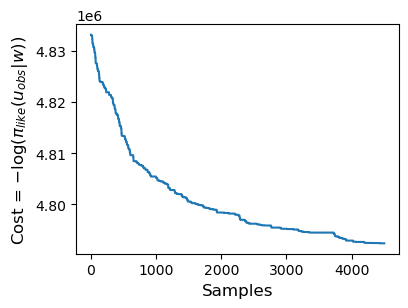

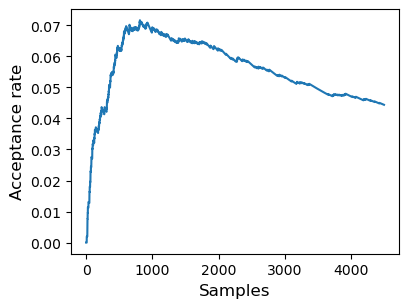

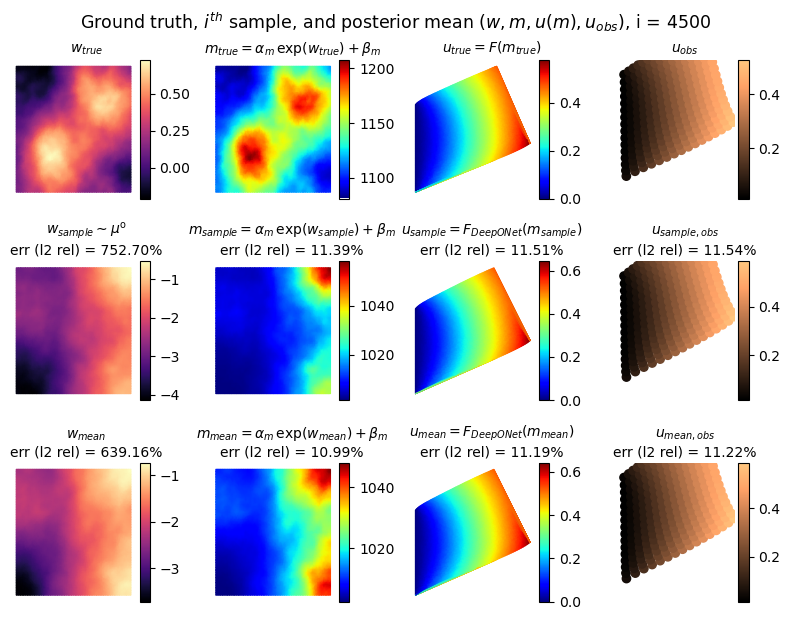

--------------------------------------------------
Sample: 5500, Accepted samples:  230, Acceptance Rate: 4.182e-02, Cost mean: 4.800e+06. 
Tracing 500 samples took 5.226e+02s
Error (%) in w: ||w - w_mean|| = 6.513e+02, ||w - w_sample|| = 7.787e+02
Error (%) in m: ||m - m_mean|| = 1.104e+01, ||m - m_sample|| = 1.152e+01
Error (%) in u: ||u - u_mean|| = 1.123e+01, ||u - u_sample|| = 1.156e+01
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 1.127e+01, ||u_obs - u_obs_sample|| = 1.158e+01
--------------------------------------------------
--------------------------------------------------
Sample: 6000, Accepted samples:  241, Acceptance Rate: 4.017e-02, Cost mean: 4.799e+06. 
Tracing 500 samples took 5.140e+02s
Error (%) in w: ||w - w_mean|| = 6.635e+02, ||w - w_sample|| = 7.914e+02
Error (%) in m: ||m - m_mean|| = 1.110e+01, ||m - m_sample|| = 1.158e+01
Error (%) in u: ||u - u_mean|| = 1.127e+01, ||u - u_sample|| = 1.158e+01
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 1.130e+01, ||u_obs - 

In [ ]:
mcmc.surrogate_to_use = "DeepONet"
mcmc.surrogate_models = surrogate_models

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, "true_model")

os.makedirs(savepath, exist_ok=True)

run_mcmc = True

if run_mcmc or run_small_test:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=savepath + os.sep,
        init_tracer=True,
    )


## Load tracer and plot

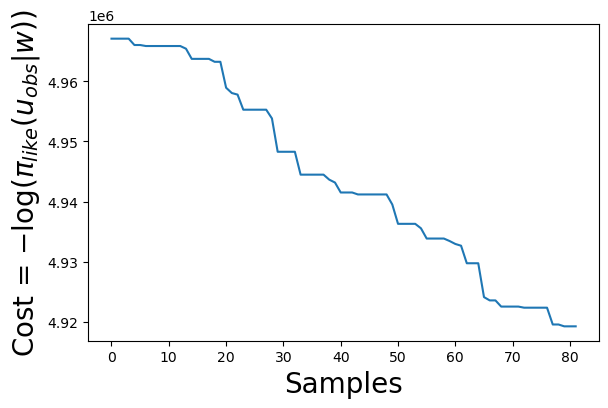

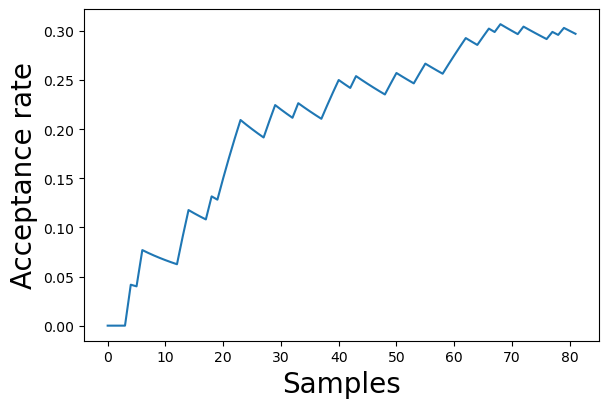

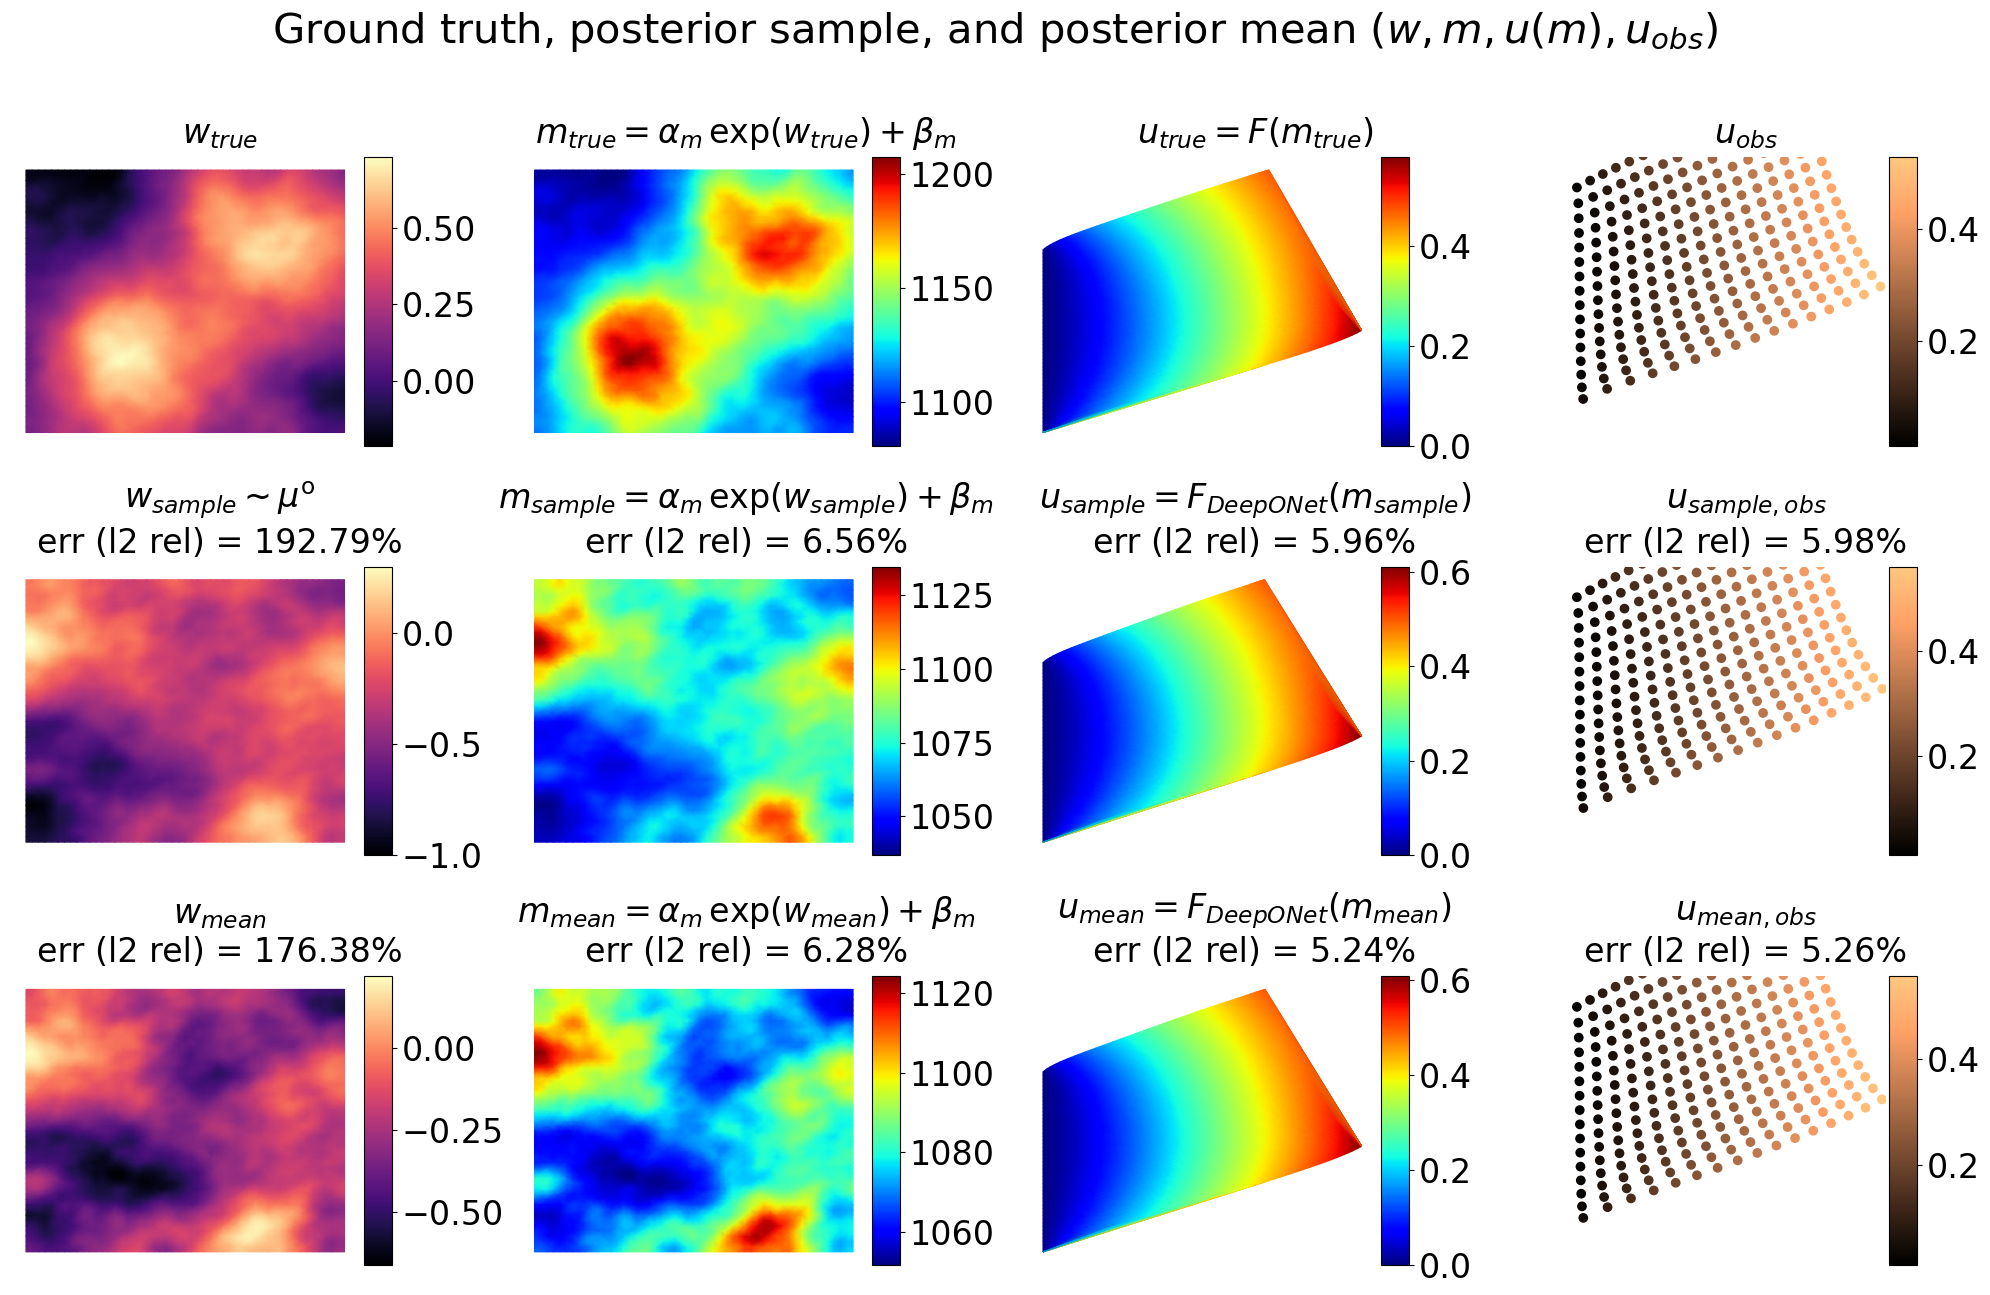

In [21]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.150_sigma_2.591e-04"
saved_results = savepath

if run_small_test:
        saved_results = savepath
        
load_tracer = pickle.load(open(os.path.join(saved_results, savefilename + ".pkl"), "rb"))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "u_vec_plot": True,
    },
}

pp_params = mcmc_pp_params["curve_plot"]
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)

w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)


# MCMC with surrogate: PCANet

In [ ]:
mcmc.surrogate_to_use = "PCANet"
mcmc.surrogate_models = surrogate_models

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, f"true_model")

os.makedirs(savepath, exist_ok=True)

run_mcmc = True

if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=savepath + os.sep,
        init_tracer=True,
    )


## Load tracer and plot

In [ ]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.150_sigma_2.591e-04"
saved_results = savepath

if run_small_test:
        saved_results = savepath
        
load_tracer = pickle.load(open(os.path.join(saved_results, savefilename + ".pkl"), "rb"))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "u_vec_plot": True,
    },
}

pp_params = mcmc_pp_params["curve_plot"]
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)

w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)


# MCMC with surrogate: FNO

In [ ]:
mcmc.surrogate_to_use = "FNO"
mcmc.surrogate_models = surrogate_models

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, f"true_model")

os.makedirs(savepath, exist_ok=True)

run_mcmc = True

if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=savepath + os.sep,
        init_tracer=True,
    )


## Load tracer and plot

In [ ]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.150_sigma_2.591e-04"
saved_results = savepath

if run_small_test:
        saved_results = savepath
        
load_tracer = pickle.load(open(os.path.join(saved_results, savefilename + ".pkl"), "rb"))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "u_vec_plot": True,
    },
}

pp_params = mcmc_pp_params["curve_plot"]
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)

w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)
